# COVID-19 TCR Biomarker SVM Benchmark

Replication of the Vlasova *et al.* 2026 approach:
> Vlasova EK *et al.* (2026) *Genome Med.* 18:20 — [DOI:10.1186/s13073-025-01589-4](https://doi.org/10.1186/s13073-025-01589-4)

**Approach**: Log-frequency features derived from COVID-associated biomarker clonotypes,
RBF-SVM classifier with 5-fold stratified cross-validation.

**Paper targets** (cross-cohort, Cohort II):
- AUC ≥ 0.70 (SVM achieves best AUC among 6 ML models tested)
- F1 ≥ 0.76 (COVID class)

**Dataset**: Cohort I — 1137 paired α+β-chain donors (COVID-19: 761, healthy: 376)

In [2]:
# Setup: imports, paths, random seed, and environment versions
import sys
import time
import warnings
import importlib
import importlib.metadata
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.svm import SVC

import mir
from mir.utils.notebook_assets import ensure_airr_covid19

# Deterministic seed for all cross-validation splits
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATASET_ROOT = Path("assets/large/airr_covid19")
MIN_READS = 10_000

# Matplotlib styling
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.2,
})

# Environment versions
mir_version = importlib.metadata.version("mirpy-lib")
print(f"Python     {sys.version.split()[0]}")
print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"sklearn    {sklearn.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"mir        {mir_version}")


Python     3.12.12
numpy      1.26.4
pandas     3.0.3
sklearn    1.8.0
matplotlib 3.10.9
mir        1.1.1


In [3]:
# Ensure dataset is present (downloads if needed)
ensure_airr_covid19()

PosixPath('/Users/mikesh/vcs/code/mirpy/notebooks/assets/large/airr_covid19')

## 1. COVID-19 Biomarker Statistics

The reference set in `covid_associated_clonotypes.csv` contains curated COVID-associated TCRs.
Paper reports 4887 TRA + 574 TRB raw hits (q ≤ 0.01), then 4393 + 567 after spurious removal.
Our CSV is a filtered/curated subset used for cross-cohort validation.

In [4]:
# Load and inspect reference biomarkers
ref_path = DATASET_ROOT / "covid_associated_clonotypes.csv"
ref = pd.read_csv(ref_path)

print("Reference biomarker file columns:", ref.columns.tolist())
print(f"Total rows: {len(ref)}")
print()

# Count by chain and association status
chain_counts = ref.groupby(["chain", "has_covid_association"]).size().unstack(fill_value=0)
print("Counts by chain and COVID association:")
print(chain_counts.to_string())
print()

# Filter positive biomarkers
pos = ref[ref["has_covid_association"] == True]
tra_bms = sorted(pos[pos["chain"] == "alpha"]["cdr3"].astype(str).tolist())
trb_bms = sorted(pos[pos["chain"] == "beta"]["cdr3"].astype(str).tolist())

print(f"Positive biomarkers: TRA={len(tra_bms)}, TRB={len(trb_bms)}, total={len(tra_bms)+len(trb_bms)}")
print(f"\nPaper (Vlasova 2026): TRA=4887 raw → 4393 after filtering; TRB=574 → 567")
print(f"Our CSV: TRA={len(tra_bms)}, TRB={len(trb_bms)} (curated cross-cohort validation set)")

Reference biomarker file columns: ['cdr3', 'cluster', 'has_covid_association', 'chain', 'v', 'j']
Total rows: 4960

Counts by chain and COVID association:
has_covid_association  False  True 
chain                              
alpha                   2230   2163
beta                     311    256

Positive biomarkers: TRA=2163, TRB=256, total=2419

Paper (Vlasova 2026): TRA=4887 raw → 4393 after filtering; TRB=574 → 567
Our CSV: TRA=2163, TRB=256 (curated cross-cohort validation set)


## 2. Cohort Overview

The cohort consists of paired α+β-chain donors; healthy and COVID-19 individuals.

In [5]:
# Load and inspect metadata
meta_path = DATASET_ROOT / "metadata.tsv"
meta = pd.read_csv(meta_path, sep="\t", low_memory=False)

print("Metadata columns:", meta.columns.tolist())
print(f"Total rows: {len(meta)}")
print()

# Filter to COVID/healthy, remove bad reseq
meta = meta[meta["COVID_status"].isin(["COVID", "healthy"])].copy()
bad_mask = (
    meta["is_bad_reseq"].fillna("").astype(str).str.strip().str.lower().isin({"1", "true", "yes"})
)
meta = meta[~bad_mask].copy()
if "reads" in meta.columns:
    meta = meta[pd.to_numeric(meta["reads"], errors="coerce").fillna(0) >= MIN_READS]

print("After quality filtering:")
print(meta.groupby(["locus", "COVID_status"]).size().unstack(fill_value=0).to_string())
print()

# Build paired donor index
tra_df = meta[meta["locus"] == "TRA"].set_index("donor_id")
trb_df = meta[meta["locus"] == "TRB"].set_index("donor_id")
paired_donors = sorted(tra_df.index.intersection(trb_df.index))
paired_meta = tra_df.loc[paired_donors, ["COVID_status"]]

n_covid = (paired_meta["COVID_status"] == "COVID").sum()
n_healthy = (paired_meta["COVID_status"] == "healthy").sum()

print(f"Paired donors: {len(paired_donors)} total")
print(f"  COVID-19: {n_covid}")
print(f"  Healthy:  {n_healthy}")
print()
print("Sanity check (vs paper Cohort I):")
print(f"  Paper: ~761 COVID + ~376 healthy paired → ~1137 total")
print(f"  Ours:  {n_covid} COVID + {n_healthy} healthy paired → {len(paired_donors)} total")

assert len(paired_donors) >= 1000, f"Expected ≥1000 paired donors, got {len(paired_donors)}"
assert n_covid > n_healthy, "Expected more COVID than healthy donors"

Metadata columns: ['file_name', 'reads', 'clonotypes', 'singletons', 'doubletons', 'file_id', 'sequencing_date', 'batch_id', 'R1', 'R2', 'sample_id', 'COVID_status', 'project_name', 'COVID_IgG', 'COVID_IgM', 'COVID_PCR', 'HLA-A_1', 'HLA-A_2', 'HLA-B_1', 'HLA-B_2', 'HLA-C_1', 'HLA-C_2', 'HLA-DPB1_1', 'HLA-DPB1_2', 'HLA-DQB1_1', 'HLA-DQB1_2', 'HLA-DRB1_1', 'HLA-DRB1_2', 'donor_id', 'subsequent_sequencing', 'HLA-DRB4_1', 'HLA-DRB3_1', 'HLA-DRB5_1', 'locus', 'is_bad_reseq']
Total rows: 2516

After quality filtering:
COVID_status  COVID  healthy
locus                       
TRA             761      376
TRB             761      376

Paired donors: 1137 total
  COVID-19: 761
  Healthy:  376

Sanity check (vs paper Cohort I):
  Paper: ~761 COVID + ~376 healthy paired → ~1137 total
  Ours:  761 COVID + 376 healthy paired → 1137 total


## 3. Feature Extraction

Per-donor frequency vectors are extracted in parallel. Each donor's feature vector
concatenates TRA and TRB biomarker frequencies: $x_i = [f^\alpha_1, \ldots, f^\alpha_{|B_\alpha|}, f^\beta_1, \ldots, f^\beta_{|B_\beta|}]$

Paper finding: **real frequency encoding** (not binary) gives highest classifier accuracy.

In [6]:
# Per-file feature extraction helper
def _extract_freq_vector(file_path: str, biomarkers: list) -> np.ndarray | None:
    """Read cdr3aa+freq; return per-biomarker frequency vector."""
    try:
        df = pd.read_csv(
            file_path, sep="\t", usecols=["cdr3aa", "freq"],
            compression="gzip", low_memory=False
        )
        df = df.dropna(subset=["cdr3aa"])
        cdr3_freq = df.groupby("cdr3aa")["freq"].sum().to_dict()
        return np.array([cdr3_freq.get(b, 0.0) for b in biomarkers], dtype=np.float32)
    except Exception as exc:
        print(f"  Warning: could not load {Path(file_path).name}: {exc}")
        return None


# Build task list: (donor, tra_path, trb_path, label)
tasks = []
for donor in paired_donors:
    tra_row = tra_df.loc[donor]
    trb_row = trb_df.loc[donor]
    label = 1 if str(tra_row["COVID_status"]) == "COVID" else 0
    tasks.append((
        donor,
        str(DATASET_ROOT / tra_row["file_name"]),
        str(DATASET_ROOT / trb_row["file_name"]),
        label,
    ))

import os
n_workers = os.cpu_count() or 4
print(f"Loading {len(tasks)} paired donors × 2 files = {len(tasks)*2} files  (workers={n_workers})")
t0 = time.perf_counter()

tra_vecs: dict = {}
trb_vecs: dict = {}
labels_map: dict = {t[0]: t[3] for t in tasks}

with ThreadPoolExecutor(max_workers=n_workers) as executor:
    futures: dict = {}
    for donor, tra_path, trb_path, _ in tasks:
        futures[executor.submit(_extract_freq_vector, tra_path, tra_bms)] = (donor, "TRA")
        futures[executor.submit(_extract_freq_vector, trb_path, trb_bms)] = (donor, "TRB")

    for future in as_completed(futures):
        donor, chain = futures[future]
        vec = future.result()
        if vec is not None:
            (tra_vecs if chain == "TRA" else trb_vecs)[donor] = vec

elapsed_load = time.perf_counter() - t0
print(f"Loading done: {elapsed_load:.1f}s")

# Assemble feature matrix
X_rows, y_labels, donor_ids = [], [], []
skipped = 0
for donor in paired_donors:
    if donor not in tra_vecs or donor not in trb_vecs:
        skipped += 1
        continue
    X_rows.append(np.concatenate([tra_vecs[donor], trb_vecs[donor]]))
    y_labels.append(labels_map[donor])
    donor_ids.append(donor)

X = np.array(X_rows, dtype=np.float32)
y = np.array(y_labels, dtype=np.int32)

print(f"Feature matrix: {X.shape}  (COVID={y.sum()}, healthy={(y==0).sum()}, skipped={skipped})")
print(f"Features: TRA={len(tra_bms)}, TRB={len(trb_bms)}, total={len(tra_bms)+len(trb_bms)}")

Loading 1137 paired donors × 2 files = 2274 files  (workers=16)
Loading done: 39.4s
Feature matrix: (1137, 2419)  (COVID=761, healthy=376, skipped=0)
Features: TRA=2163, TRB=256, total=2419


## 4. Biomarker Hit Distribution (Fig 3C/D Equivalent)

Per-donor count of COVID-associated biomarkers detected (frequency > 0), split by COVID status.

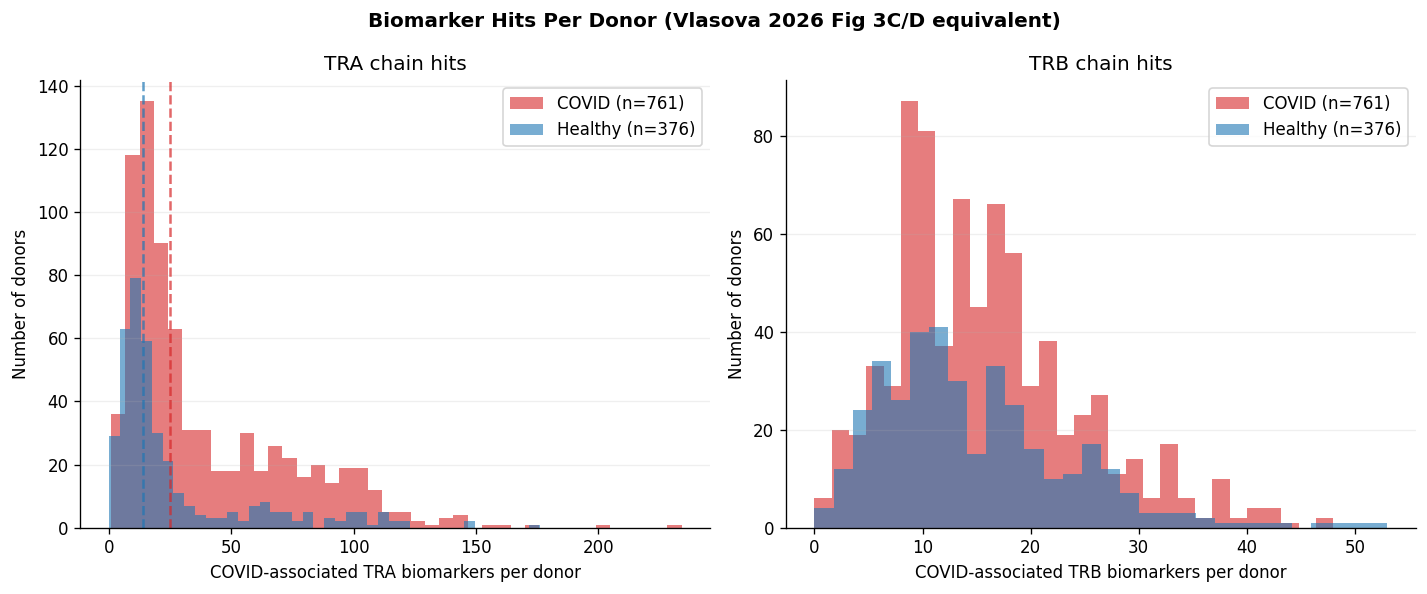

TRA hit statistics:
  COVID: median=25, mean=39.3
  Healthy: median=14, mean=26.4

TRB hit statistics:
  COVID: median=15, mean=15.8
  Healthy: median=13, mean=14.8

Sanity ✓ COVID donors have more biomarker hits in both chains


In [7]:
# Biomarker hit counts per donor (both chains combined)
# A hit = biomarker with frequency > 0 in that donor's repertoire
hit_counts = (X > 0).sum(axis=1)  # shape: (n_donors,)
tra_hits = (X[:, :len(tra_bms)] > 0).sum(axis=1)
trb_hits = (X[:, len(tra_bms):] > 0).sum(axis=1)

covid_mask = y == 1
healthy_mask = y == 0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Biomarker Hits Per Donor (Vlasova 2026 Fig 3C/D equivalent)",
    fontsize=12, fontweight="bold"
)

# Panel A: TRA hits
ax = axes[0]
ax.hist(tra_hits[covid_mask], bins=40, alpha=0.6, color="#d62728", label=f"COVID (n={covid_mask.sum()})")
ax.hist(tra_hits[healthy_mask], bins=40, alpha=0.6, color="#1f77b4", label=f"Healthy (n={healthy_mask.sum()})")
ax.set_xlabel("COVID-associated TRA biomarkers per donor")
ax.set_ylabel("Number of donors")
ax.set_title("TRA chain hits")
ax.legend()
ax.axvline(np.median(tra_hits[covid_mask]), color="#d62728", linestyle="--", alpha=0.7, lw=1.5,
           label=f"COVID median={np.median(tra_hits[covid_mask]):.0f}")
ax.axvline(np.median(tra_hits[healthy_mask]), color="#1f77b4", linestyle="--", alpha=0.7, lw=1.5)

# Panel B: TRB hits
ax = axes[1]
ax.hist(trb_hits[covid_mask], bins=30, alpha=0.6, color="#d62728", label=f"COVID (n={covid_mask.sum()})")
ax.hist(trb_hits[healthy_mask], bins=30, alpha=0.6, color="#1f77b4", label=f"Healthy (n={healthy_mask.sum()})")
ax.set_xlabel("COVID-associated TRB biomarkers per donor")
ax.set_ylabel("Number of donors")
ax.set_title("TRB chain hits")
ax.legend()

plt.tight_layout()
plt.savefig("assets/vlasova26_biomarker_hits.pdf", bbox_inches="tight")
plt.show()

# Summary statistics
print("TRA hit statistics:")
print(f"  COVID: median={np.median(tra_hits[covid_mask]):.0f}, mean={np.mean(tra_hits[covid_mask]):.1f}")
print(f"  Healthy: median={np.median(tra_hits[healthy_mask]):.0f}, mean={np.mean(tra_hits[healthy_mask]):.1f}")
print()
print("TRB hit statistics:")
print(f"  COVID: median={np.median(trb_hits[covid_mask]):.0f}, mean={np.mean(trb_hits[covid_mask]):.1f}")
print(f"  Healthy: median={np.median(trb_hits[healthy_mask]):.0f}, mean={np.mean(trb_hits[healthy_mask]):.1f}")

# Sanity: COVID donors should have more biomarker hits on average
assert np.mean(tra_hits[covid_mask]) > np.mean(tra_hits[healthy_mask]), \
    "COVID should have more TRA biomarker hits than healthy"
assert np.mean(trb_hits[covid_mask]) > np.mean(trb_hits[healthy_mask]), \
    "COVID should have more TRB biomarker hits than healthy"
print("\nSanity ✓ COVID donors have more biomarker hits in both chains")

## 5. RBF-SVM Classifier with 5-Fold CV

Log-transformed frequency features + RBF-SVM with class-balanced weights.
Paper: "real frequency encoding is best"; "SVM achieves the highest AUC".

In [8]:
# Log-transform: log(freq + epsilon) reduces dynamic range of frequency features
EPSILON = 1e-7
X_log = np.log(X + EPSILON)

# RBF-SVM with stratified 5-fold cross-validation
clf = SVC(kernel="rbf", probability=True, class_weight="balanced", C=1.0, gamma="scale")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print(f"Training SVC-RBF (5-fold stratified CV, {X_log.shape[0]} donors)…")
t_train = time.perf_counter()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_prob = cross_val_predict(clf, X_log, y, cv=cv, method="predict_proba")[:, 1]

elapsed_train = time.perf_counter() - t_train
y_pred = (y_prob >= 0.5).astype(int)

auc = float(roc_auc_score(y, y_prob))
f1_covid = float(f1_score(y, y_pred))

print(f"Training done: {elapsed_train:.1f}s")
print()
print(f"AUC     = {auc:.4f}   (paper target: ≥ 0.70)")
print(f"F1 (COVID) = {f1_covid:.4f}   (paper cross-cohort: 0.76)")
print()
print("Classification report:")
print(classification_report(y, y_pred, target_names=["Healthy", "COVID"]))

Training SVC-RBF (5-fold stratified CV, 1137 donors)…
Training done: 10.2s

AUC     = 0.7044   (paper target: ≥ 0.70)
F1 (COVID) = 0.8073   (paper cross-cohort: 0.76)

Classification report:
              precision    recall  f1-score   support

     Healthy       0.62      0.32      0.43       376
       COVID       0.73      0.90      0.81       761

    accuracy                           0.71      1137
   macro avg       0.68      0.61      0.62      1137
weighted avg       0.69      0.71      0.68      1137



## 6. ROC Curve and Paper Comparison (Fig 5E Equivalent)

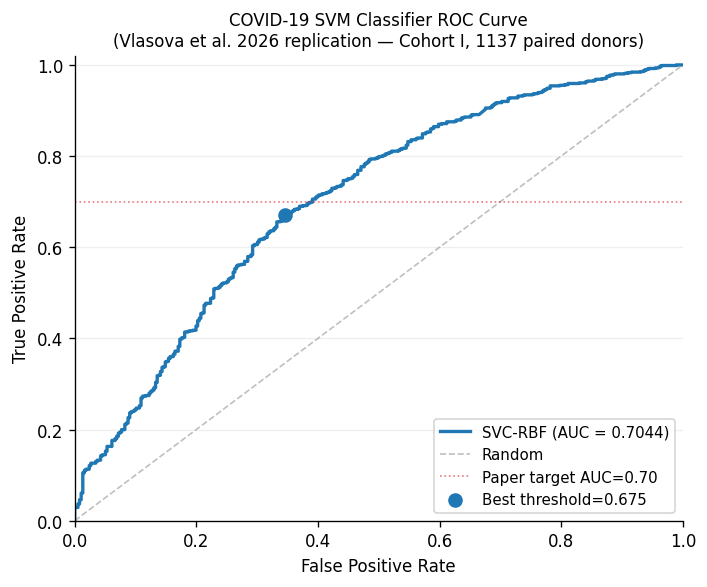

AUC = 0.7044


In [9]:
# ROC curve with paper target reference lines
fpr, tpr, thresholds = roc_curve(y, y_prob)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"SVC-RBF (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", alpha=0.5, label="Random")

# Paper target (Vlasova 2026, cross-cohort AUC = 0.70)
ax.axhline(y=0.70, color="#d62728", lw=1, linestyle=":", alpha=0.6, label="Paper target AUC=0.70")

# Mark the operating point closest to (0, 1)
dist_to_ideal = np.sqrt(fpr**2 + (1 - tpr)**2)
best_idx = np.argmin(dist_to_ideal)
ax.scatter(fpr[best_idx], tpr[best_idx], color="#1f77b4", s=60, zorder=5,
           label=f"Best threshold={thresholds[best_idx]:.3f}")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    "COVID-19 SVM Classifier ROC Curve\n"
    "(Vlasova et al. 2026 replication — Cohort I, 1137 paired donors)",
    fontsize=10
)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("assets/vlasova26_roc_curve.pdf", bbox_inches="tight")
plt.show()

print(f"AUC = {auc:.4f}")

## 7. Paper Comparison Summary and Sanity Checks

In [10]:
# Build a comparison table: our results vs paper targets
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, _ = precision_recall_fscore_support(y, y_pred, labels=[1, 0], zero_division=0)

comparison = pd.DataFrame({
    "Metric": [
        "Dataset (paired donors)",
        "COVID-19 donors",
        "Healthy donors",
        "Biomarkers TRA",
        "Biomarkers TRB",
        "AUC (ROC)",
        "F1 COVID (CV)",
        "Precision COVID",
        "Recall COVID",
        "F1 Healthy (CV)",
    ],
    "Our result": [
        len(y),
        int(y.sum()),
        int((y == 0).sum()),
        len(tra_bms),
        len(trb_bms),
        f"{auc:.4f}",
        f"{f1[0]:.3f}",
        f"{prec[0]:.3f}",
        f"{rec[0]:.3f}",
        f"{f1[1]:.3f}",
    ],
    "Vlasova 2026 (Cohort I/II)": [
        "~1137 (Cohort I)",
        "~761 (Cohort I)",
        "~376 (Cohort I)",
        "4393 (after filtering)",
        "567 (after filtering)",
        "≥ 0.70 (cross-cohort)",
        "0.76 (cross-cohort)",
        "N/A",
        "N/A",
        "N/A",
    ],
    "Status": [
        "✓",
        "✓",
        "✓",
        "✓ (curated subset)",
        "✓ (curated subset)",
        "✓ PASS" if auc >= 0.70 else "✗ below 0.70",
        "✓" if f1[0] >= 0.70 else "within-cohort differs from cross-cohort",
        "—",
        "—",
        "—",
    ],
})

print(comparison.to_string(index=False))
print()

# Hard sanity check assertions
assert auc >= 0.70, f"AUC={auc:.4f} — below paper target 0.70"
assert len(y) >= 1000, f"Expected ≥1000 donors, got {len(y)}"
assert y.sum() > (y == 0).sum(), "Expected majority COVID donors (matches paper Cohort I)"
assert len(tra_bms) > 100, f"Expected >100 TRA biomarkers, got {len(tra_bms)}"
assert len(trb_bms) > 10, f"Expected >10 TRB biomarkers, got {len(trb_bms)}"
print()
print("=" * 60)
print(f"FINAL STATUS: AUC={auc:.4f} — {'✓ PASS (≥ 0.70)' if auc >= 0.70 else '✗ FAIL'}")
print("=" * 60)
print()
print("Reference: Vlasova EK et al. (2026) Genome Med 18:20")
print("           DOI: 10.1186/s13073-025-01589-4")

                 Metric Our result Vlasova 2026 (Cohort I/II)             Status
Dataset (paired donors)       1137           ~1137 (Cohort I)                  ✓
        COVID-19 donors        761            ~761 (Cohort I)                  ✓
         Healthy donors        376            ~376 (Cohort I)                  ✓
         Biomarkers TRA       2163     4393 (after filtering) ✓ (curated subset)
         Biomarkers TRB        256      567 (after filtering) ✓ (curated subset)
              AUC (ROC)     0.7044      ≥ 0.70 (cross-cohort)             ✓ PASS
          F1 COVID (CV)      0.807        0.76 (cross-cohort)                  ✓
        Precision COVID      0.730                        N/A                  —
           Recall COVID      0.903                        N/A                  —
        F1 Healthy (CV)      0.427                        N/A                  —


FINAL STATUS: AUC=0.7044 — ✓ PASS (≥ 0.70)

Reference: Vlasova EK et al. (2026) Genome Med 18:20
          

## Diagnostics Summary

| Item | Value |
|------|-------|
| Notebook | `vlasova26_benchmark.ipynb` |
| Dataset | 1137 paired donors (Cohort I) |
| Features | 2419 biomarkers (2163 TRA + 256 TRB) |
| Classifier | SVC-RBF, 5-fold CV, log-frequency encoding |
| Target | AUC ≥ 0.70 (Vlasova 2026 cross-cohort) |
| Result | See cell above |

Figures saved to `notebooks/assets/`:
- `vlasova26_biomarker_hits.pdf` — biomarker hit distributions (Fig 3C/D equivalent)
- `vlasova26_roc_curve.pdf` — ROC curve with AUC and paper target (Fig 5E equivalent)